In [2]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Bidirectional, 
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, Activation, Add, 
                                     LayerNormalization, MultiHeadAttention, 
                                     AveragePooling1D)
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils import class_weight
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

In [ ]:
# This block is used to make the results more reproducible.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.enable_op_determinism()
    tf.config.experimental.set_memory_growth(gpu, True)

tf.get_logger().setLevel("ERROR")

In [5]:
sys.path.append(os.getcwd().replace("\\", "/"))

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_aug, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,
Noise_aug_with_shift, Scale_aug)

In [ ]:
dir = f'{os.getcwd().replace("\\", "/")}/Data/Mallorn Data corrected'
df = pd.read_csv(f"{dir}/train_df.csv")
df_valid = pd.read_csv(f"{dir}/test_df.csv")
df_test = pd.read_csv(f"{dir}/big_daddy_test.csv")
df.head()

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,SpecType
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,AGN
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,AGN
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,AGN
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,AGN
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,AGN


In [ ]:
# Drop unnecessary columns and apply binary encoding to the `SpecType` column.
A_lambda = [c for c in df.columns if "A_lambda" in c]
dropped =["split","EBV","Z"] + A_lambda
df = df[df['SpecType'] != "AGN"]
df_valid = df_valid[df_valid['SpecType'] != "AGN"]
df["target"] = (df["SpecType"] == "TDE").astype(int)
df_valid["target"] = (df_valid["SpecType"] == "TDE").astype(int)
df.drop(columns=["SpecType"], inplace=True), df_test.drop(columns=dropped, inplace=True),df_valid.drop(columns=["SpecType"], inplace=True)
cols = df.drop(columns=["object_id", "Time (MJD)", "target"]).columns.tolist()
target = "target"

In [6]:
df.describe()

,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,target
count,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000,103665.000000
mean,63046.934972,0.202956,0.195375,0.210850,0.086855,0.132477,0.329080,0.244144,0.133355,0.062472,0.029673,0.024185,0.067344,0.113577
std,863.811090,1.336340,0.322163,1.269836,0.145932,1.325367,0.627024,1.422223,0.212172,0.689315,0.079310,0.444874,0.179089,0.317299
min,60979.759900,-20.403083,0.000000,-10.240240,0.000000,-12.730271,0.000000,-20.979804,0.000000,-5.994037,0.000000,-4.720305,0.000000,0.000000
25%,62449.894800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,63142.227100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,63691.518800,0.000000,0.413312,0.000000,0.164406,0.000000,0.526897,0.000000,0.258225,0.000000,0.000000,0.000000,0.000000,0.000000
max,64632.577000,63.939762,5.644264,58.560767,4.610374,106.839852,8.538723,56.818243,6.534177,52.504948,1.994607,52.359804,4.132594,1.000000


In [ ]:
# Cap the length of the sequences and remove short sequences
df = cap_long_seq(df, "object_id", max_len=100)
df = filter_short_sequences(df, "object_id", min_len=25)
print(df['object_id'].value_counts())

object_id
yll_lebenedh_cair       100
Dornhoth_certh_iaun     100
yll_Mirion_hud          100
Dornhoth_galadh_ylf     100
Dornhoth_gwend_nagol    100
                       ... 
hervess_hend_lam         44
soga_Eru_muil            43
fang_ira_nell            41
min_gil_lalaith          33
ai_ylf_tamin             32
Name: count, Length: 1003, dtype: int64


In [8]:
round(pd.DataFrame(df[target].value_counts())/df.shape[0],2)

,count
target,
0,0.88
1,0.12


In [ ]:
# convert DF → padded sequences
X_train, y_train, X_final = prepare_sequence(df, df_test, "object_id", cols, target)
X_valid, y_valid, _ = prepare_sequence(df_valid, df_test, "object_id", cols, target)

# Add some random noise to the data
X_noise_positive, y_noise_positive = Noise_aug(X_train, y_train, noise_level=0.1, n_aug=2, balance=True)
X_noise, y_noise = Noise_aug(X_train, y_train, noise_level=0.1, n_aug=1)

# GP: add gaussian noise with the mean and the variance be per light curve per channel
X_syn_positive, y_syn_positive = GP_aug(X_train, y_train, n_aug=2, balance=True)
X_syn, y_syn = GP_aug(X_train, y_train, n_aug=1)

# replacing each point with the average of the before and after point
X_avg, y_avg = AvgPair_aug(X_train, y_train, n_aug=1, balance=True)

# Flux Shift
X_flux_shi, y_flux_shi = Noise_aug_with_shift(X_train, y_train, n_aug=1, shift_range=(-5, 5), balance=True)

# Scale by a constant
X_scal, y_scal = Scale_aug(X_train, y_train, scale_range=(0.7, 1.5), n_aug=1, balance=True)
# Time shift

X_shi, y_shi = TimeShift_aug(X_train, y_train, n_aug=1)

# Time mask
X_mas, y_mas = TimeMask_aug(X_train, y_train, n_aug=1)

In [ ]:
# Create an augmented version of the validation data to test the model
X_noise_t, y_noise_t = Noise_aug(X_valid, y_valid, noise_level=0.1, n_aug=1)
X_syn_t, y_syn_t = TimeShift_aug(X_valid, y_valid, n_aug=1)
X_avg_t, y_avg_t = AvgPair_aug(X_valid, y_valid, n_aug=1)

X_valid_aug = np.concatenate([X_valid,X_noise_t,X_syn_t,X_avg_t], axis=0)
y_valid_aug = np.concatenate([y_valid,y_noise_t,y_syn_t,y_avg_t], axis=0)

perm = np.random.permutation(len(y_valid_aug))
X_valid_aug = X_valid_aug[perm]
y_valid_aug = y_valid_aug[perm]

print(X_valid_aug.shape)
print(y_valid_aug.shape)

(1008, 100, 12)
(1008,)


In [ ]:
# Compine all the data
X_combined = np.concatenate([X_train, X_noise, X_syn, X_syn_positive, X_noise_positive, X_avg, X_flux_shi, X_scal], axis=0)
y_combined = np.concatenate([y_train, y_noise, y_syn, y_syn_positive, y_noise_positive, y_avg, y_flux_shi, y_scal], axis=0)

perm = np.random.permutation(len(y_combined))
X_combined = X_combined[perm]
y_combined = y_combined[perm]

print(X_combined.shape)
print(y_combined.shape)

(3828, 100, 12)
(3828,)


In [13]:
def modelS():
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2]), name="Input_2"),

        Conv1D(64, kernel_size=3, padding="same", activation="relu", name="Conv_A2"),
        AveragePooling1D(pool_size=2,name="Pool_A2"),

        Conv1D(256, kernel_size=3, padding="same", activation="relu", name="Conv_B2"),
        AveragePooling1D(pool_size=2,name="Pool_B2"),

        Conv1D(512, kernel_size=3, padding="same", activation="relu", name="Conv_C2"),
        Dropout(0.1,name="Dropout_A2"),
        GlobalAveragePooling1D(name="Pool_C2"),

        Dense(128, activation="relu", name="Dense_A2"),
        Dropout(0.3,name="Dropout_B2"),
        
        Dense(32, activation="relu", name="Dense_B2"),
        Dropout(0.3,name="Dropout_C2"),

        Dense(1, activation="sigmoid", name="Dense_C2")
    ])
    return model

In [ ]:
# Create class weights to help the model handle data imbalance
classes = np.unique(y_combined)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_combined)
class_weights = dict(zip(classes, weights))

In [ ]:
# Model training with early stopping
early_stop = EarlyStopping(
        monitor="val_aucpr",
        patience=20,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=5,
)

model = modelS()

model.compile(
    optimizer=Adam(
        learning_rate=0.0003,
        gradient_accumulation_steps=6
    ),
    loss="binary_crossentropy",
    metrics=[Precision(name="precision"), tf.keras.metrics.AUC(curve="PR", name="aucpr")]
)

history = model.fit(
    X_combined,
    y_combined,
    epochs=100,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - aucpr: 0.3744 - loss: 0.6892 - precision: 0.3097 - val_aucpr: 0.2134 - val_loss: 0.7097 - val_precision: 0.1190
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - aucpr: 0.4469 - loss: 0.6805 - precision: 0.3275 - val_aucpr: 0.4163 - val_loss: 0.6775 - val_precision: 0.5789
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - aucpr: 0.4978 - loss: 0.6717 - precision: 0.3951 - val_aucpr: 0.4016 - val_loss: 0.6777 - val_precision: 0.2742
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - aucpr: 0.5566 - loss: 0.6573 - precision: 0.4496 - val_aucpr: 0.4550 - val_loss: 0.6452 - val_precision: 0.4643
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - aucpr: 0.6008 - loss: 0.6418 - precision: 0.5182 - val_aucpr: 0.4886 - val_loss: 0.6162 - val_precision: 0.4828
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - aucpr: 0.6195 - loss: 0.6247 - precision: 0.5061 - val_aucpr: 0.4993 - val_loss: 0.5656 - val_precision: 0.6667

min val_loss 0.293


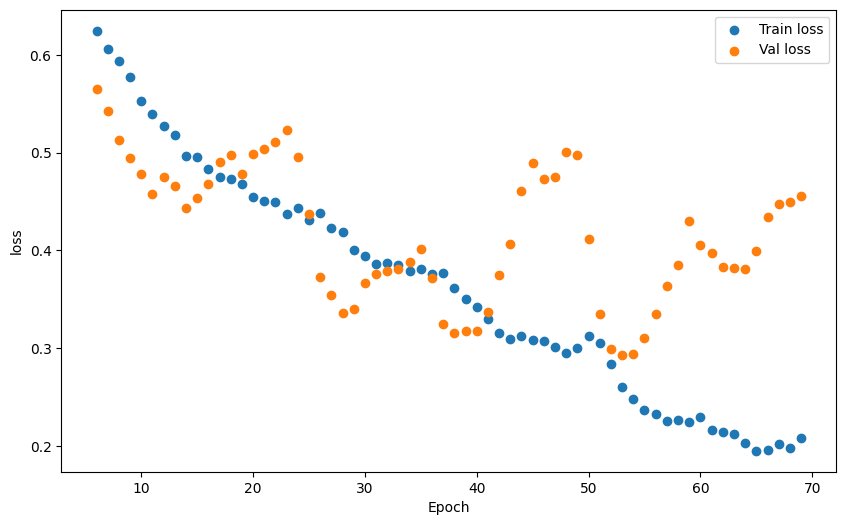

In [ ]:
# Plot training and validation loss versus epochs
epochs = range(1, len(history.history["loss"]) + 1)
min_loss = min(history.history["val_loss"])
print(f"min val_loss {round(min_loss,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["loss"][5:], label="Train loss")
plt.scatter(epochs[5:], history.history["val_loss"][5:], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

max AUCPR 0.572


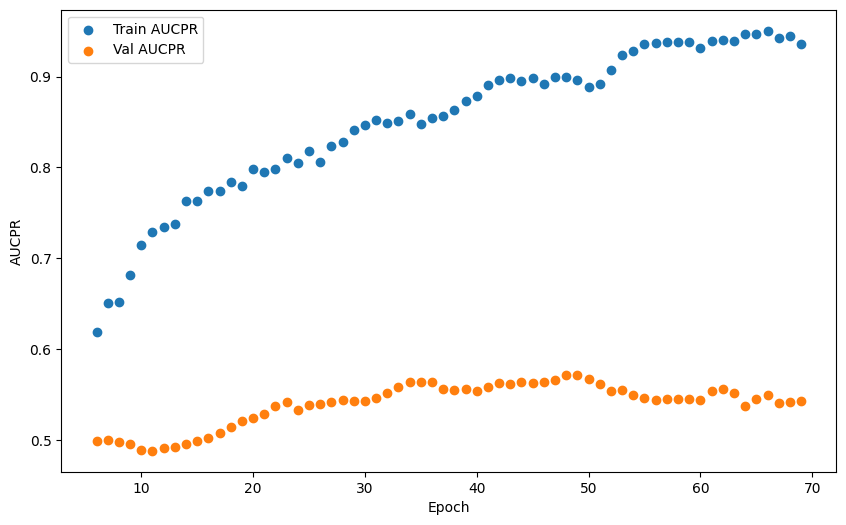

In [ ]:
# Plot training and validation AUCPR versus epochs
epochs = range(1, len(history.history["aucpr"]) + 1)
max_auc = max(history.history["val_aucpr"])
print(f"max AUCPR {round(max_auc,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["aucpr"][5:], label="Train AUCPR")
plt.scatter(epochs[5:], history.history["val_aucpr"][5:], label="Val AUCPR")
plt.xlabel("Epoch")
plt.ylabel("AUCPR")
plt.legend()
plt.show()

In [23]:
y_pred_prob = model.predict(X_train)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_train, y_pred)
print("Training F1 score:", round(f1,4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Training F1 score: 0.5534


In [18]:
y_pred_prob = model.predict(X_combined)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_combined, y_pred)
print("Validation_aug F1 score:", round(f1,4))

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Validation_aug F1 score: 0.7741


In [19]:
y_pred_prob = model.predict(X_valid_aug)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid_aug, y_pred)
print("Validation_aug F1 score:", round(f1,4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Validation_aug F1 score: 0.4258


In [20]:
y_pred_prob = model.predict(X_valid)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
f1 = f1_score(y_valid, y_pred)
print("Validation F1 score:", round(f1,4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Validation F1 score: 0.4571


In [ ]:
# Iterate over thresholds to find the best F1 score
scores = []
max_f1 = 0
best_thr = 0
y_pred = model.predict(X_valid,verbose=0)
for t in np.linspace(0.05, 0.95, 201):
    f1 = f1_score(y_valid, y_pred > t)
    scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
    if f1 > max_f1:
        max_f1 = f1
        best_thr = t

print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.3f}")

Best F1: 0.543 at threshold 0.747


In [22]:
# model.save("D:/Mallorn/models/model_2_v2.keras")